In [1]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/analysis_ready.csv",parse_dates=["date"])
df.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,units_sold_was_missing,category,subcategory,launch_date,unit_cost,list_price,week,month,season,is_holiday,promo_event
0,2024-01-01,SKU0001,4.0,1158.68,289.67,0,0,Furniture,Sofas,2025-04-03,129.5,289.67,1,1,Winter,1,No Promo
1,2024-01-02,SKU0001,2.0,579.34,289.67,0,0,Furniture,Sofas,2025-04-03,129.5,289.67,1,1,Winter,0,No Promo
2,2024-01-03,SKU0001,2.0,579.34,289.67,0,0,Furniture,Sofas,2025-04-03,129.5,289.67,1,1,Winter,0,No Promo
3,2024-01-04,SKU0001,4.0,1158.68,289.67,0,0,Furniture,Sofas,2025-04-03,129.5,289.67,1,1,Winter,0,No Promo
4,2024-01-05,SKU0001,2.0,579.34,289.67,0,0,Furniture,Sofas,2025-04-03,129.5,289.67,1,1,Winter,0,No Promo


In [2]:
# Basic shape check
print("Rows:",len(df))
print("Number of unique SKUs:", df["sku_id"].nunique())
print("Date range:",df["date"].min(),"to",df["date"].max())
df.columns.tolist()


Rows: 146200
Number of unique SKUs: 200
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


['date',
 'sku_id',
 'units_sold',
 'revenue',
 'unit_price',
 'promo_flag',
 'units_sold_was_missing',
 'category',
 'subcategory',
 'launch_date',
 'unit_cost',
 'list_price',
 'week',
 'month',
 'season',
 'is_holiday',
 'promo_event']

In [3]:
# Best Selling and Worst Selling Products 

totals = df.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False)

print("Top 5 best-selling SKUs:")
print(totals.head(5))

print("\n Bottom 5 worst-selling SKUs:")
print(totals.tail(5))


Top 5 best-selling SKUs:
sku_id
SKU0100    23825.0
SKU0083    23523.0
SKU0030    23414.0
SKU0176    23147.0
SKU0133    23121.0
Name: units_sold, dtype: float64

 Bottom 5 worst-selling SKUs:
sku_id
SKU0070    409.0
SKU0200    405.0
SKU0134    379.0
SKU0031    368.0
SKU0126    363.0
Name: units_sold, dtype: float64


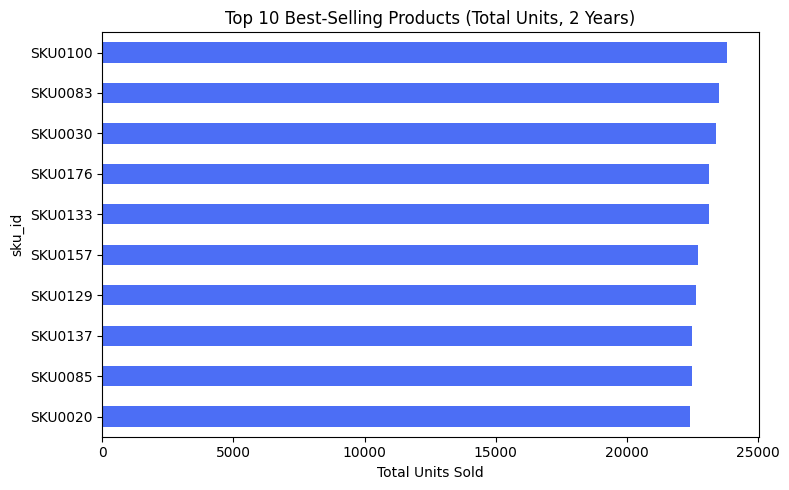

In [4]:
# Visualize it as a chart
top10 = totals.head(10)

fig, ax= plt.subplots(figsize=(8,5))
top10.plot(kind="barh",ax=ax , color="#4C6EF5")
ax.set_title("Top 10 Best-Selling Products (Total Units, 2 Years)")
ax.set_xlabel("Total Units Sold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


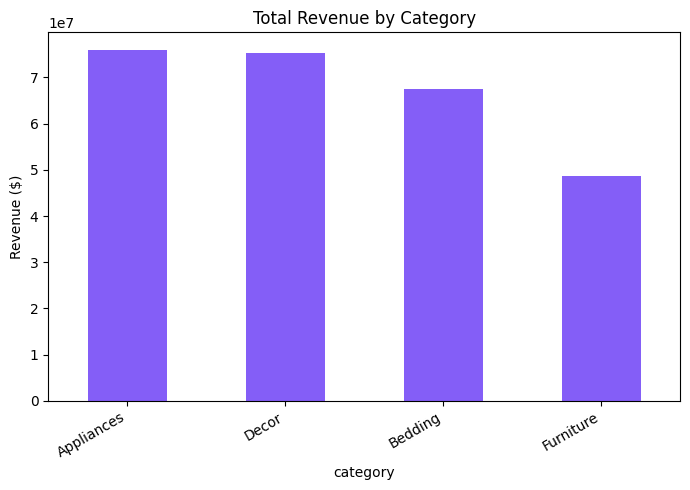

category
Appliances    75962072.64
Decor         75376333.31
Bedding       67424401.84
Furniture     48755367.12
Name: revenue, dtype: float64

In [7]:
# Revenue by category

cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig, ax =plt.subplots(figsize=(7,5))
cat_rev.plot(kind="bar",ax=ax,color="#845EF7")
ax.set_title("Total Revenue by Category")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

cat_rev


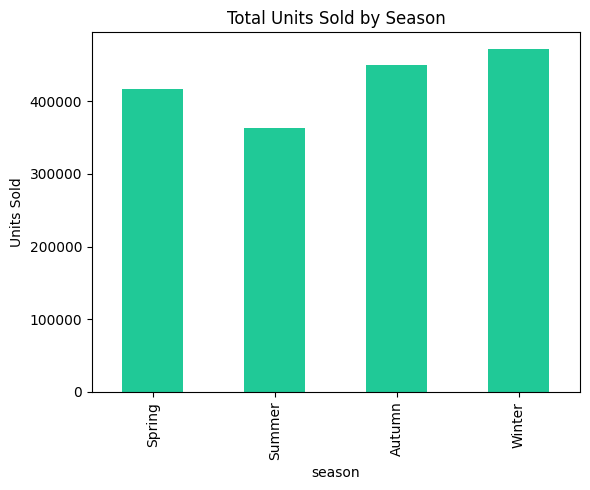

season
Spring    417416.0
Summer    363550.0
Autumn    450299.0
Winter    471343.0
Name: units_sold, dtype: float64

In [8]:
# Seasonality Check
season_order = ["Spring", "Summer", "Autumn", "Winter"]
season_units = df.groupby("season") ["units_sold"].sum().reindex(season_order)

fig , ax = plt.subplots(figsize=(6,5))
season_units.plot(kind="bar",ax=ax, color="#20C997")
ax.set_title("Total Units Sold by Season")
ax.set_ylabel("Units Sold")
plt.tight_layout()
plt.show()

season_units


In [9]:
# Do Promotions actually work?

promo_avg = df.groupby("promo_flag")["units_sold"].mean()
lift_pct = (promo_avg[1]/ promo_avg[0]- 1)*100

print("Average daily units sold - no promo:", round(promo_avg[0],2))
print("Average daily units sold - with promo:", round(promo_avg[1],2))
print(f"Promo Lift: {lift_pct:.1f}%")

Average daily units sold - no promo: 11.22
Average daily units sold - with promo: 16.79
Promo Lift: 49.7%


In [10]:
# Identify Dead Stock
threshold = totals.quantile(0.15)
dead_stock = totals[totals <= threshold]

print(f"{len(dead_stock)} SKUs sold {threshold:.0f} units or fewer over 2 years")
print("These are dead_stock/ markdown candidates:")
dead_stock


30 SKUs sold 486 units or fewer over 2 years
These are dead_stock/ markdown candidates:


sku_id
SKU0161    483.0
SKU0164    474.0
SKU0008    466.0
SKU0193    460.0
SKU0091    459.0
SKU0154    452.0
SKU0117    445.0
SKU0155    437.0
SKU0184    437.0
SKU0142    434.0
SKU0105    434.0
SKU0068    433.0
SKU0073    432.0
SKU0146    427.0
SKU0012    426.0
SKU0098    425.0
SKU0171    424.0
SKU0046    424.0
SKU0180    422.0
SKU0053    419.0
SKU0141    417.0
SKU0101    415.0
SKU0138    412.0
SKU0002    411.0
SKU0064    409.0
SKU0070    409.0
SKU0200    405.0
SKU0134    379.0
SKU0031    368.0
SKU0126    363.0
Name: units_sold, dtype: float64

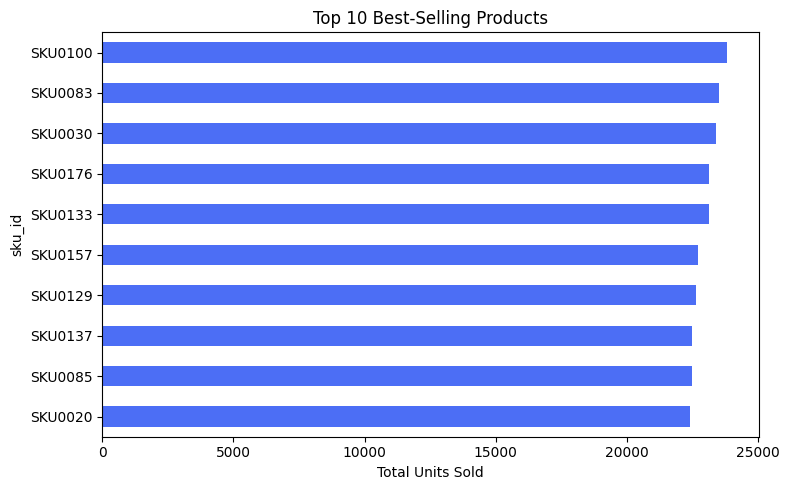

In [11]:
import os
os.makedirs("../reports/figures", exist_ok=True)

# Re-save each chart to a file
top10.plot(kind="barh", figsize=(8,5), color="#4C6EF5", title="Top 10 Best-Selling Products").invert_yaxis()
plt.xlabel("Total Units Sold")
plt.tight_layout()
plt.savefig("../reports/figures/top10_sellers.png", dpi=120)
plt.show()


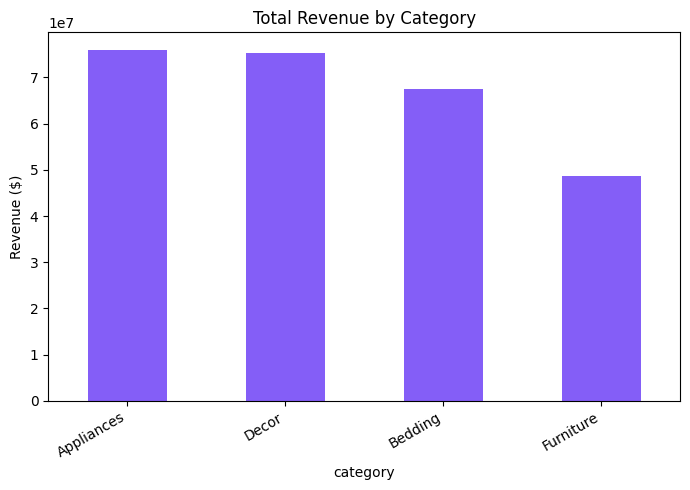

In [13]:
# Revenue by category (for reporting)
cat_rev.plot(kind="bar" , figsize=(7,5) ,color="#845EF7", title="Total Revenue by Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_category.png", dpi=120)
plt.show()


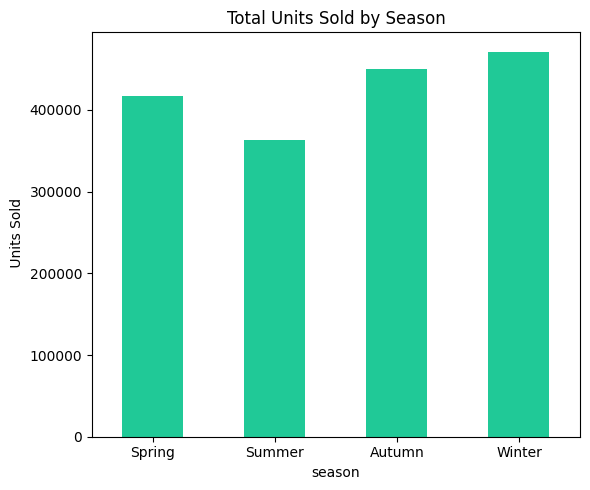

In [15]:
# Seasonality
season_units.plot(kind="bar", figsize=(6,5), color="#20C997", title="Total Units Sold by Season")
plt.ylabel(" Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/seasonality.png", dpi=120)
plt.show()
